# Assignment 1

In [133]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

## Task 1: Loading and retrieving RGB channels of an image (1 Mark)

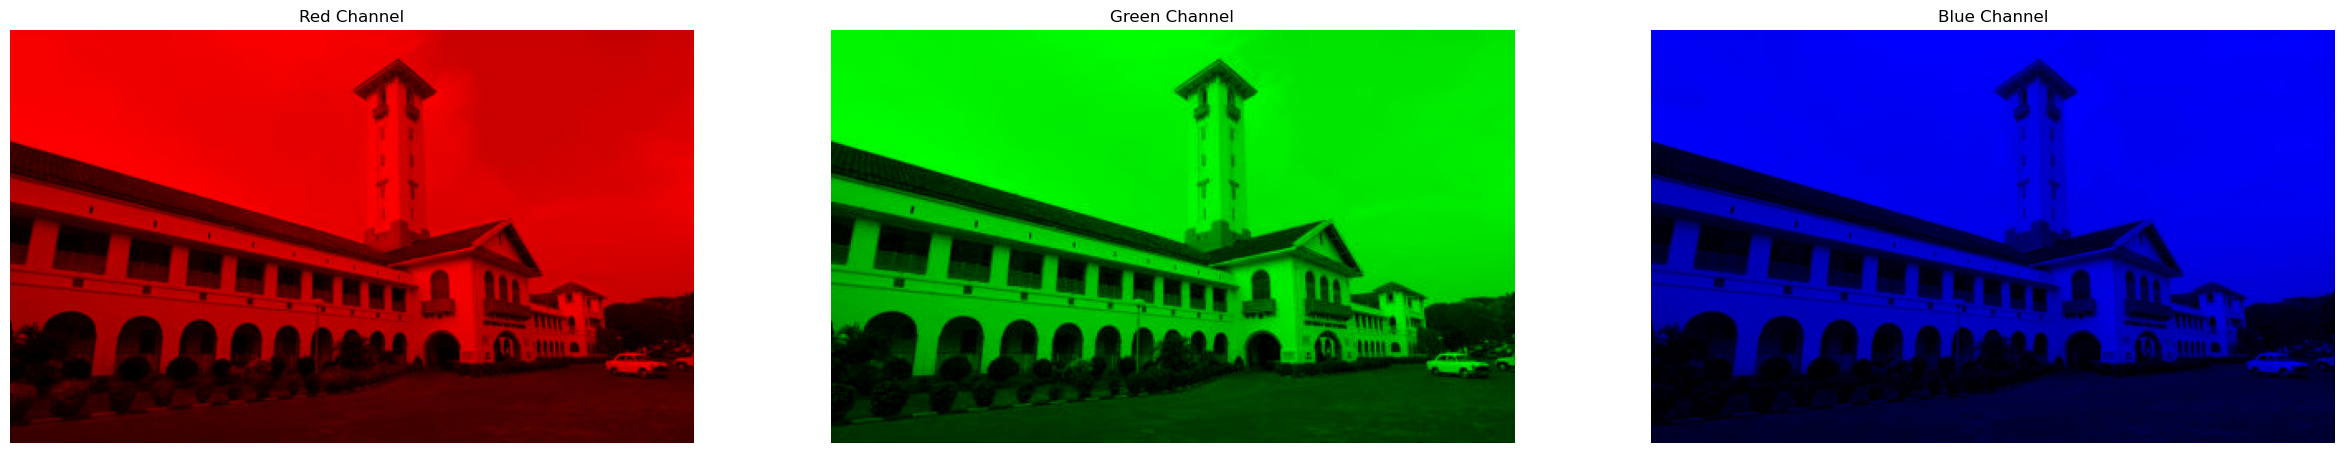

In [134]:
imgA = cv2.imread("./assets/imageA.jpeg")
imgA = cv2.cvtColor(imgA, cv2.COLOR_BGR2RGB)
imgA_red, imgA_green, imgA_blue = cv2.split(imgA)

# Merging channels such that only 1 channel has their respective color and the others as zeros, so only that channel's color can be observed
imgA_red = cv2.merge([imgA_red, np.zeros_like(imgA_red), np.zeros_like(imgA_red)])
imgA_green = cv2.merge([np.zeros_like(imgA_green), imgA_green, np.zeros_like(imgA_green)])
imgA_blue = cv2.merge([np.zeros_like(imgA_blue), np.zeros_like(imgA_blue), imgA_blue])

# Plotting each channel image
fig, axes = plt.subplots(1, 3, figsize=(30, 10))
axes[0].imshow(imgA_red)
axes[0].axis('off')
axes[0].set_title("Red Channel")
axes[1].imshow(imgA_green)
axes[1].axis('off')
axes[1].set_title("Green Channel")
axes[2].imshow(imgA_blue)
axes[2].axis('off')
axes[2].set_title("Blue Channel")
plt.show()

## Task 2: Color Space Conversion (3+3=6 Marks)

### HSV Colour Space

#### Step 1: Normalize RGB

In [135]:
imgA = cv2.imread('./assets/imageA.jpeg', cv2.IMREAD_COLOR)
imgA = cv2.cvtColor(imgA, cv2.COLOR_BGR2RGB)
imgA_red, imgA_green, imgA_blue = cv2.split(imgA)
imgA_red_N = imgA_red/255
imgA_green_N = imgA_green/255
imgA_blue_N = imgA_blue/255

#### Step 2: Calculate H, S, V

In [136]:
V = np.zeros((imgA.shape[0], imgA.shape[1]))
V = np.maximum.reduce([imgA_red_N, imgA_green_N, imgA_blue_N])
min_RGB = np.minimum.reduce([imgA_red_N, imgA_green_N, imgA_blue_N])
S = np.where(V == 0, 0, (V-min_RGB)/V)
H = np.zeros((imgA.shape[0], imgA.shape[1]))

# Finding the respective piecewise function for H, and if not found, H holds it old value, and is passed for the next checkV
H = np.where(V == imgA_red_N, (imgA_green_N - imgA_blue_N)/(V - min_RGB), H)
H = np.where(V == imgA_green_N, 2 + (imgA_blue_N - imgA_red_N)/(V - min_RGB), H)
H = np.where(V == imgA_blue_N, 4 + (imgA_red_N - imgA_blue_N)/(V - min_RGB), H)
H = np.where(H > 0, H*60, H + 360)

/tmp/ipykernel_3693/3215898300.py:4: RuntimeWarning: invalid value encountered in divide
  S = np.where(V == 0, 0, (V-min_RGB)/V)
/tmp/ipykernel_3693/3215898300.py:8: RuntimeWarning: invalid value encountered in divide
  H = np.where(V == imgA_red_N, (imgA_green_N - imgA_blue_N)/(V - min_RGB), H)
/tmp/ipykernel_3693/3215898300.py:9: RuntimeWarning: invalid value encountered in divide
  H = np.where(V == imgA_green_N, 2 + (imgA_blue_N - imgA_red_N)/(V - min_RGB), H)
/tmp/ipykernel_3693/3215898300.py:10: RuntimeWarning: invalid value encountered in divide
  H = np.where(V == imgA_blue_N, 4 + (imgA_red_N - imgA_blue_N)/(V - min_RGB), H)


In [137]:
imgA_hsv = cv2.cvtColor(imgA, cv2.COLOR_RGB2HSV)
H_cv, S_cv, V_cv = cv2.split(imgA_hsv)

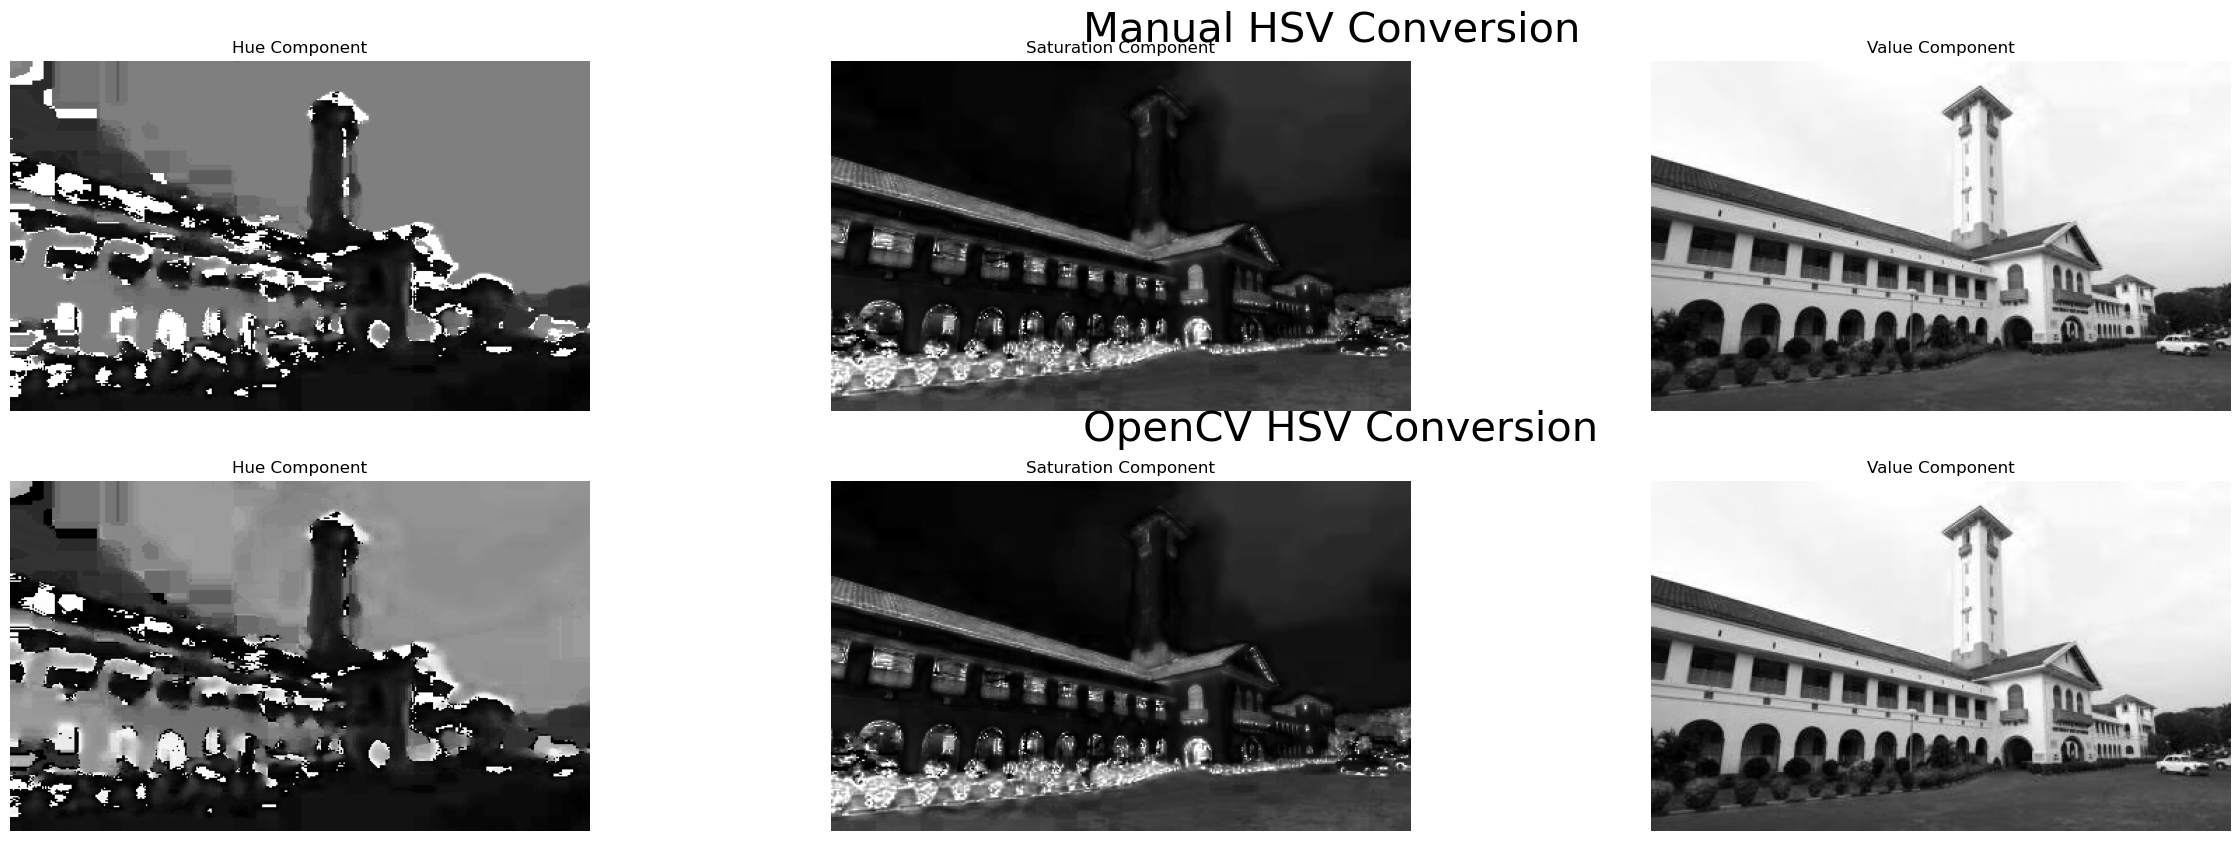

In [138]:
fig, axes = plt.subplots(2, 3, figsize=(30, 10))
fig.text(0.5, 0.9, "Manual HSV Conversion", fontsize=30)
axes[0, 0].imshow(H, cmap='grey')
axes[0, 0].axis('off')
axes[0, 0].set_title("Hue Component")
axes[0, 1].imshow(S, cmap='grey')
axes[0, 1].axis('off')
axes[0, 1].set_title("Saturation Component")
axes[0, 2].imshow(V, cmap='grey')
axes[0, 2].axis('off')
axes[0, 2].set_title("Value Component")
fig.text(0.5, 0.5, "OpenCV HSV Conversion", fontsize=30)
axes[1, 0].imshow(H_cv, cmap='grey')
axes[1, 0].axis('off')
axes[1, 0].set_title("Hue Component")
axes[1, 1].imshow(S_cv, cmap='grey')
axes[1, 1].axis('off')
axes[1, 1].set_title("Saturation Component")
axes[1, 2].imshow(V_cv, cmap='grey')
axes[1, 2].axis('off')
axes[1, 2].set_title("Value Component")
plt.show()

### Lab Colour Space

#### Step 1: Normalize RGB

In [139]:
imgA = cv2.imread('./assets/imageA.jpeg', cv2.IMREAD_COLOR)
imgA = cv2.cvtColor(imgA, cv2.COLOR_BGR2RGB)
imgA_red, imgA_green, imgA_blue = cv2.split(imgA)
imgA_red_N = imgA_red/255
imgA_green_N = imgA_green/255
imgA_blue_N = imgA_blue/255

#### Step 2: Applied inverse gamma correction

In [140]:
def invGammaCorrection(matrix):
    matrix = np.where(matrix > 0.04045, ((matrix + 0.055)/1.055)**2.4, matrix/12.92);
    return matrix

imgA_red_inv = invGammaCorrection(imgA_red_N)
imgA_green_inv = invGammaCorrection(imgA_green_N)
imgA_blue_inv = invGammaCorrection(imgA_blue_N)

#### Step 3: Linear RGB to XYZ

In [141]:
imgA_X = 0.4124564*imgA_red_inv + 0.3575761*imgA_green_inv + 0.1804375*imgA_blue_inv
imgA_Y = 0.2126729*imgA_red_inv + 0.7151522*imgA_green_inv + 0.0721750*imgA_blue_inv
imgA_Z = 0.0193339*imgA_red_inv + 0.1191920*imgA_green_inv + 0.9503041*imgA_blue_inv

#### Step 4: Normalize for the white point

In [142]:
imgA_x = imgA_X/0.95047
imgA_y = imgA_Y/1.0
imgA_z = imgA_Z/1.08883

#### Step 5: Convert XYZ to CIELAB

In [143]:
def f(t):
    t = np.where(t > 0.008856, t**(0.3333), 7.787*t + 4/29)
    return t

# As the transformed values (imgA_x, imgA_y, imgA_z) are float values, whatever transformation we apply must be later be clipped between 0-255 and be made into the type uint8 as color as stored in that formatggV
imgA_L = (116*f(imgA_y) - 16).clip(0, 255).astype(np.uint8)
imgA_a = (500*(f(imgA_x) - f(imgA_y))).clip(0, 255).astype(np.uint8)
imgA_b = (200*(f(imgA_y) - f(imgA_z))).clip(0, 255).astype(np.uint8)
imgA_a_offset = (500*(f(imgA_x) - f(imgA_y)) + 128).clip(0, 255).astype(np.uint8)
imgA_b_offset = (200*(f(imgA_y) - f(imgA_z)) + 128).clip(0, 255).astype(np.uint8)

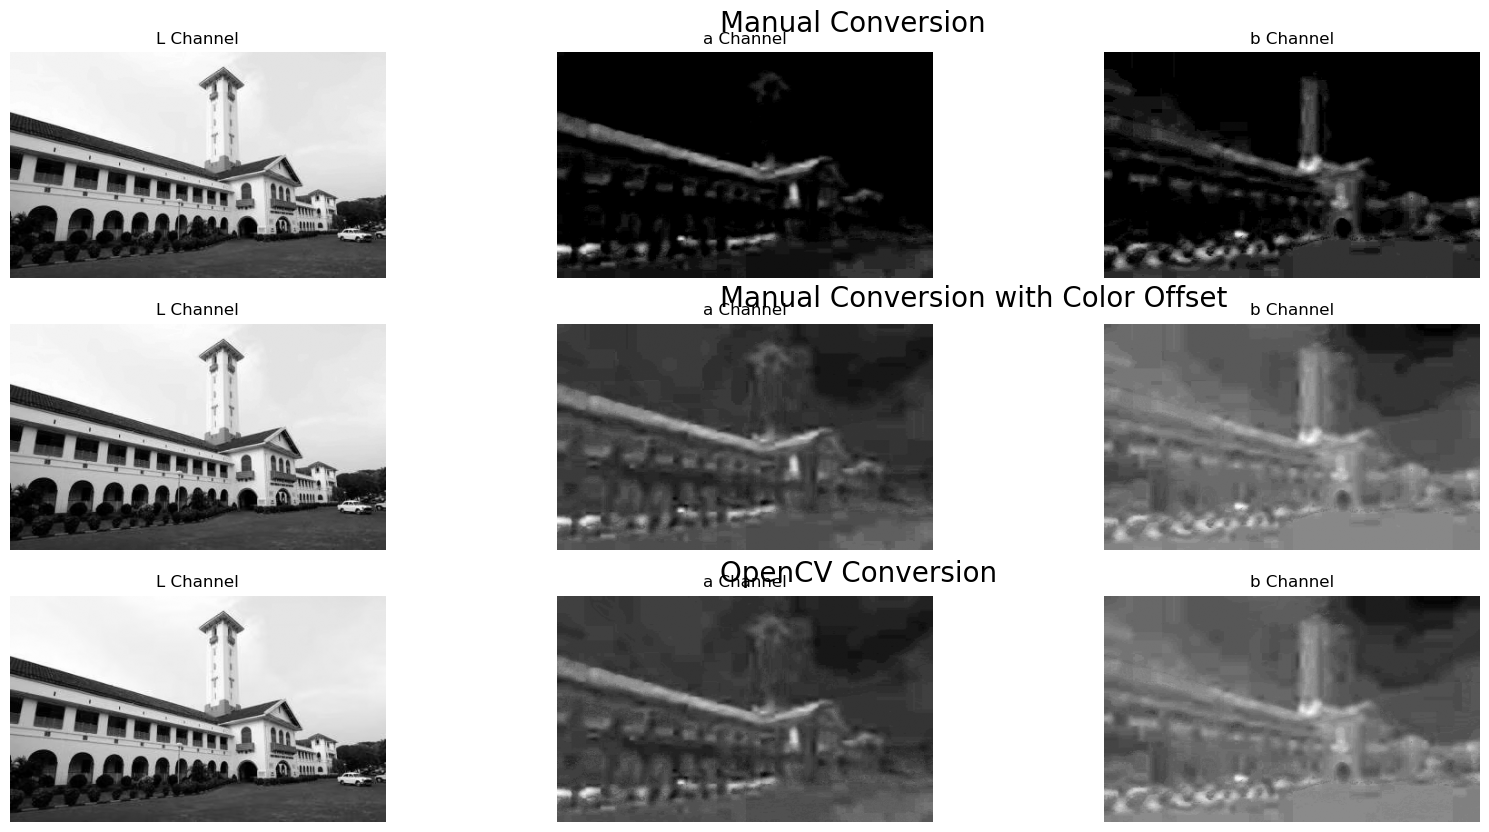

In [144]:
imgA = cv2.imread('./assets/imageA.jpeg', cv2.IMREAD_COLOR_RGB)
fig, axes = plt.subplots(3, 3, figsize=(20,10))
fig.text(0.5, 0.9, "Manual Conversion", fontsize=20)
axes[0, 0].imshow(imgA_L, cmap='grey')
axes[0, 0].axis('off')
axes[0, 0].set_title("L Channel")
axes[0, 1].imshow(imgA_a, cmap='grey')
axes[0, 1].axis('off')
axes[0, 1].set_title("a Channel")
axes[0, 2].imshow(imgA_b, cmap='grey')
axes[0, 2].axis('off')
axes[0, 2].set_title("b Channel")
fig.text(0.5, 0.625, "Manual Conversion with Color Offset", fontsize=20)
axes[1, 0].imshow(imgA_L, cmap='grey')
axes[1, 0].axis('off')
axes[1, 0].set_title("L Channel")
axes[1, 1].imshow(imgA_a_offset, cmap='grey')
axes[1, 1].axis('off')
axes[1, 1].set_title("a Channel")
axes[1, 2].imshow(imgA_b_offset, cmap='grey')
axes[1, 2].axis('off')
axes[1, 2].set_title("b Channel")
imgA_LAB = cv2.cvtColor(imgA, cv2.COLOR_RGB2LAB)
fig.text(0.5, 0.35, "OpenCV Conversion", fontsize=20)
axes[2, 0].imshow(imgA_LAB[...,0], cmap='grey')
axes[2, 0].axis('off')
axes[2, 0].set_title("L Channel")
axes[2, 1].imshow(imgA_LAB[...,1], cmap='grey')
axes[2, 1].axis('off')
axes[2, 1].set_title("a Channel")
axes[2, 2].imshow(imgA_LAB[...,2], cmap='grey')
axes[2, 2].axis('off')
axes[2, 2].set_title("b Channel")
plt.show()

## Task 3: Bilinear interpolation (3 Marks)

Text(0.5, 1.0, 'OpenCV Resized Cropped Image')

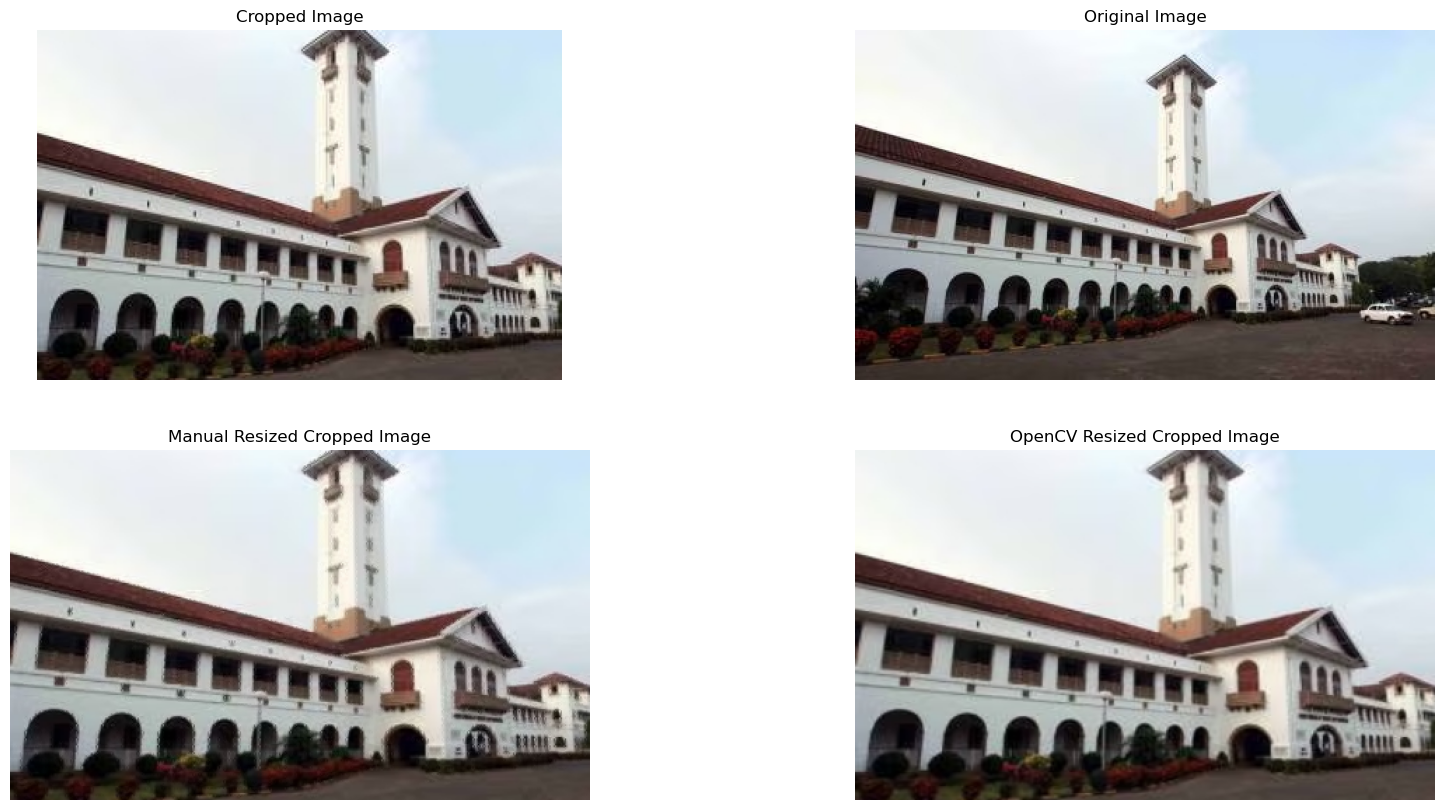

In [145]:
import math
height = 200; width = 300;
x = (int)(imgA.shape[1]/2 - width/2)
y = (int)(imgA.shape[0]/2 - height/2)
imgA_cropped = imgA[y:y+height, x:x+width]

def bilinear_interpolation(img, new_height, new_width):
    old_height, old_width, channels = img.shape
    if new_height != 0 and new_width != 0 :
        x_scale_factor, y_scale_factor = old_width/new_width, old_height/new_height
    else :
        x_scale_factor, y_scale_factor = 0, 0

    new_img = np.zeros((new_height, new_width, channels))

    for i in range(new_height):
        for j in range(new_width):
            y_interpolated, x_interpolated = i*y_scale_factor, j*x_scale_factor
            x_ceil, x_floor, y_ceil, y_floor = min(math.ceil(x_interpolated), old_width-1), math.floor(x_interpolated), min(math.ceil(y_interpolated), old_height-1), math.floor(y_interpolated)

            reference_color_TR = img[int(y_floor), int(x_ceil), :]
            reference_color_TL = img[int(y_floor), int(x_floor), :]
            reference_color_BL = img[int(y_ceil), int(x_ceil), :]
            reference_color_BR = img[int(y_ceil), int(x_floor), :]

            # Interpolation
            # Edge case, if the point lies exactly on another pixel of the original image
            if(x_ceil == x_floor and y_ceil == y_floor):
                interpolated_colour = img[int(y_floor), int(x_floor)]
            
            #Edge case, if the point lies exactly between two pixels vertically of the original image
            elif (x_ceil == x_floor):
                top_interpolation = reference_color_TL;
                bottom_interpolation = reference_color_BL;
                interpolated_colour = (top_interpolation*(y_ceil - y_interpolated) + bottom_interpolation*(y_interpolated - y_floor))

            #Edge case, if the point lies exactly between two pixels horizontally of the original image
            elif (y_ceil == y_floor):
                left_interpolation = reference_color_TL;
                right_interpolation = reference_color_TR;
                interpolated_colour = (left_interpolation*(x_ceil - x_interpolated) + right_interpolation*(x_interpolated - x_floor))

            #General interpolation to be applied otherwise
            else:
                top_interpolation = (reference_color_TL*(x_ceil - x_interpolated) + reference_color_TR*(x_interpolated - x_floor))
                bottom_interpolation = (reference_color_BL*(x_ceil - x_interpolated) + reference_color_BR*(x_interpolated - x_floor))
                interpolated_colour = (top_interpolation*(y_ceil - y_interpolated) + bottom_interpolation*(y_interpolated - y_floor))

            new_img[i, j, :] = interpolated_colour
    
    return new_img.astype('uint8')


imgA_resized_manual = bilinear_interpolation(imgA_cropped, imgA.shape[0], imgA.shape[1])
imgA_resized_cv = cv2.resize(imgA_cropped, None, fx=imgA.shape[1]/imgA_cropped.shape[1], fy=imgA.shape[0]/imgA_cropped.shape[0], interpolation=cv2.INTER_LINEAR)

fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes[0, 0].imshow(imgA_cropped)
axes[0, 0].axis('off')
axes[0, 0].set_title("Cropped Image")
axes[0, 1].imshow(imgA)
axes[0, 1].axis('off')
axes[0, 1].set_title("Original Image")
axes[1, 0].imshow(imgA_resized_manual)
axes[1, 0].axis('off')
axes[1, 0].set_title("Manual Resized Cropped Image")
axes[1, 1].imshow(imgA_resized_cv)
axes[1, 1].axis('off')
axes[1, 1].set_title("OpenCV Resized Cropped Image")

## Task 4: Blending Images (3 Marks)

(250, 414, 3)


Text(0.5, 1.0, 'OpenCV Alpha Blended Image')

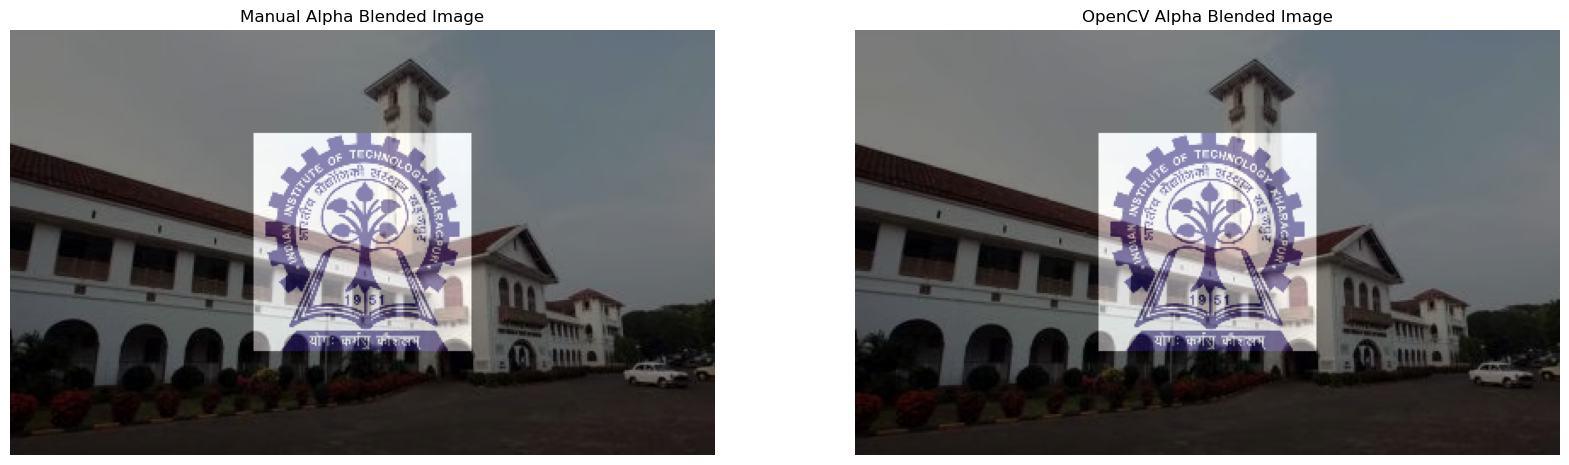

In [146]:
imgB = cv2.imread('./assets/imageB.jpg', cv2.IMREAD_COLOR_RGB)
imgB = cv2.resize(imgB, None, fx=0.25, fy=0.25, interpolation=cv2.INTER_LINEAR)

alpha = 0.5

# Finding the top left most point of the imageB which will be centered on imageA
x_topleft = int(imgA.shape[1]/2 - imgB.shape[1]/2)
y_topleft = int(imgA.shape[0]/2 - imgB.shape[0]/2)

# Initialisation of the resultant image
alpha_blended_image_manual = np.zeros((imgA.shape[0], imgA.shape[1], imgA.shape[2]))

for i in range(imgA.shape[0]):
    for j in range(imgA.shape[1]):
        # If current pixel lies on top of both imageA and to be overlayed imageC, then do alpha blending taking into account both imageA and imageB
        if ( j >= x_topleft and j < x_topleft + imgB.shape[1] and i >= y_topleft and i < y_topleft + imgB.shape[0] ):
            alpha_blended_image_manual[i, j, :] = imgA[i, j, :]*(1 - alpha) + imgB[i - y_topleft, j - x_topleft, :]*alpha
        # Else, take (1-alpha)pixel_imageA value
        else:
            alpha_blended_image_manual[i, j, :] = imgA[i, j]*(1 - alpha)

alpha_blended_image_manual = alpha_blended_image_manual.astype('uint8')

# Using OpenCV implementation
imgB_centered = np.zeros_like(imgA)
print(imgB_centered.shape)
imgB_centered[y_topleft:y_topleft+imgB.shape[0], x_topleft:x_topleft+imgB.shape[1], :] = imgB

imgA_alpha = imgA
imgA_alpha = cv2.multiply(imgA_alpha, 1-alpha)
imgB_alpha = cv2.multiply(imgB_centered, alpha)
alpha_blended_image_cv = cv2.add(imgA_alpha, imgB_alpha)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(alpha_blended_image_manual)
axes[0].axis('off')
axes[0].set_title("Manual Alpha Blended Image")
axes[1].imshow(alpha_blended_image_cv)
axes[1].axis('off')
axes[1].set_title("OpenCV Alpha Blended Image")

## Task 5: Extracting and Displaying Image Bit planes (3 Marks)

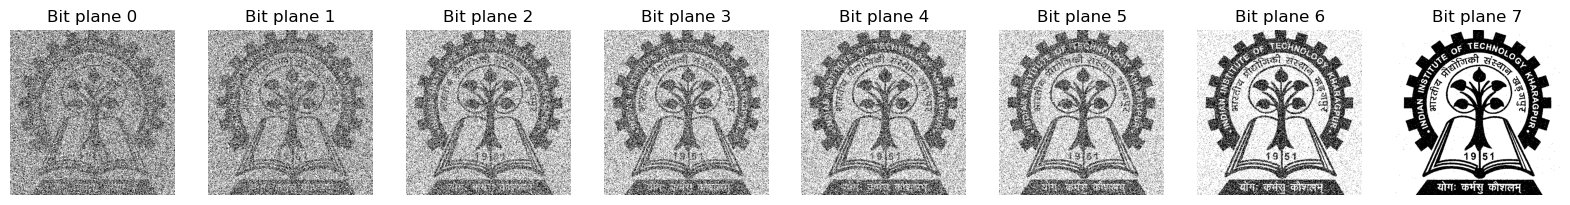

In [147]:
imgC = cv2.imread('./assets/ImageC.jpg', cv2.IMREAD_COLOR_RGB)
imgC_greyscale = cv2.cvtColor(imgC, cv2.COLOR_RGB2GRAY)

def bit_plane_slicing(img, bit_plane):
    bit_plane_image = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            bit_plane_image[i, j] = (img[i, j] & (1 << bit_plane)) >> bit_plane
    return bit_plane_image

bit_planes = [bit_plane_slicing(imgC_greyscale, i) for i in range(8)]

fig, axes = plt.subplots(1, 8, figsize=(20, 10))
for i, image in enumerate(bit_planes):
    axes[i].imshow(image*255.0, cmap="grey")
    axes[i].axis('off')
    axes[i].set_title(f"Bit plane {i}")

## Task 6: Removing Noise (3 Marks)

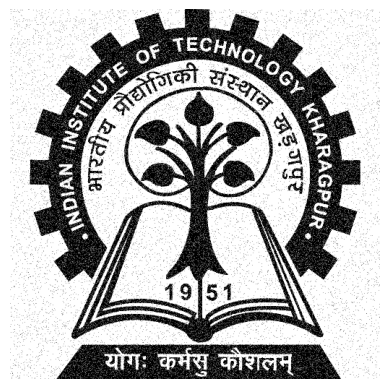

In [148]:
# As the 6th and 7th bit plane image have comparatively less noise, it will be used for the image reconstruction
imgC_reconstructed = [bit_planes[7-i] << (7-i) for i in range(2)]
imgC_reconstructed = np.sum(np.array(imgC_reconstructed, dtype=np.uint8), axis=0, dtype=np.uint8)
plt.imshow(imgC_reconstructed, cmap='grey')
plt.axis('off')
plt.show()

## Task 7: Give Explanation (1 Mark)

The least significant bits would be more prone to image pixel value changes, that is, slight variations in the pixel colours would affect the values of the first few bits. By removing the least bits, we are removing small intesity variations, which noise mostly is, while the most significant bits captures the pixel value that it best represents.